# Detailed Random Forest Training with Hyperparameter Tuning

## 1. Introduction
This notebook provides a detailed walkthrough of building a Random Forest model, including hyperparameter tuning and feature importance analysis. We will use the Breast Cancer Wisconsin dataset.

## 2. Setup and Data Loading
First, let's import the necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

# Load the dataset
cancer = load_breast_cancer()
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data['target'] = cancer.target

print("Dataset loaded successfully.")
data.head()

Dataset loaded successfully.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Data Preprocessing and Splitting
Before we build the models, we need to split the data into training and testing sets. As a tree-based model, Random Forest is not sensitive to feature scaling, so we can skip that step.

In [2]:
# Separate features and target
X = data.drop('target', axis=1)
y = data['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data split into training and testing sets successfully.
X_train shape: (455, 30)
X_test shape: (114, 30)


## 4. Initial Model Training
First, we will train a baseline Random Forest model with default parameters to see its initial performance.

In [3]:
# Create a Random Forest model with default parameters
rf_baseline = RandomForestClassifier(random_state=42)

# Train the model
rf_baseline.fit(X_train, y_train)

# Make predictions
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate the model
print("Baseline Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_baseline):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred_baseline):.2f}")

Baseline Random Forest Performance:
Accuracy: 0.96
Precision: 0.96
Recall: 0.99
F1-score: 0.97


## 5. Hyperparameter Tuning
Now, we will use GridSearchCV to find the best hyperparameters for our Random Forest model.

In [4]:
# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best parameters found:", grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


## 6. Train Final Model
Now we will train a new Random Forest model using the best hyperparameters found by GridSearchCV.

In [5]:
# Create the final model with the best parameters
best_rf_model = RandomForestClassifier(**grid_search.best_params_, random_state=42)

# Train the final model
best_rf_model.fit(X_train, y_train)

print("Final Random Forest model trained successfully.")

Final Random Forest model trained successfully.


## 7. Model Evaluation
Now we will evaluate the performance of the tuned Random Forest model on the test data.

In [6]:
# Make predictions on the test data
y_pred_final = best_rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print("Tuned Random Forest Performance:")
print(f"Accuracy: {accuracy_final:.2f}")
print(f"Precision: {precision_final:.2f}")
print(f"Recall: {recall_final:.2f}")
print(f"F1-score: {f1_final:.2f}")

Tuned Random Forest Performance:
Accuracy: 0.96
Precision: 0.96
Recall: 0.99
F1-score: 0.97


### Confusion Matrix

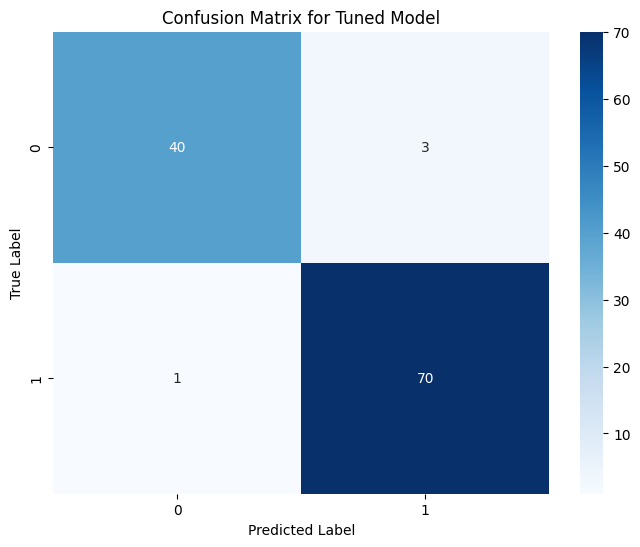

In [7]:
# Generate the confusion matrix
conf_matrix_final = confusion_matrix(y_test, y_pred_final)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_final, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### ROC Curve

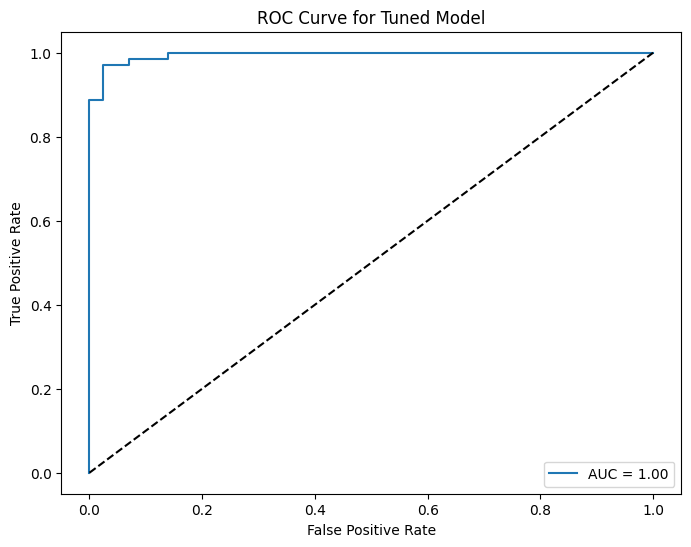

In [8]:
# Get the probability scores
y_prob_final = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr_final, tpr_final, thresholds_final = roc_curve(y_test, y_prob_final)
auc_final = roc_auc_score(y_test, y_prob_final)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_final, tpr_final, label=f'AUC = {auc_final:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Tuned Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

## 8. Feature Importance
Let's visualize the feature importances from our tuned Random Forest model to see which features were most influential.

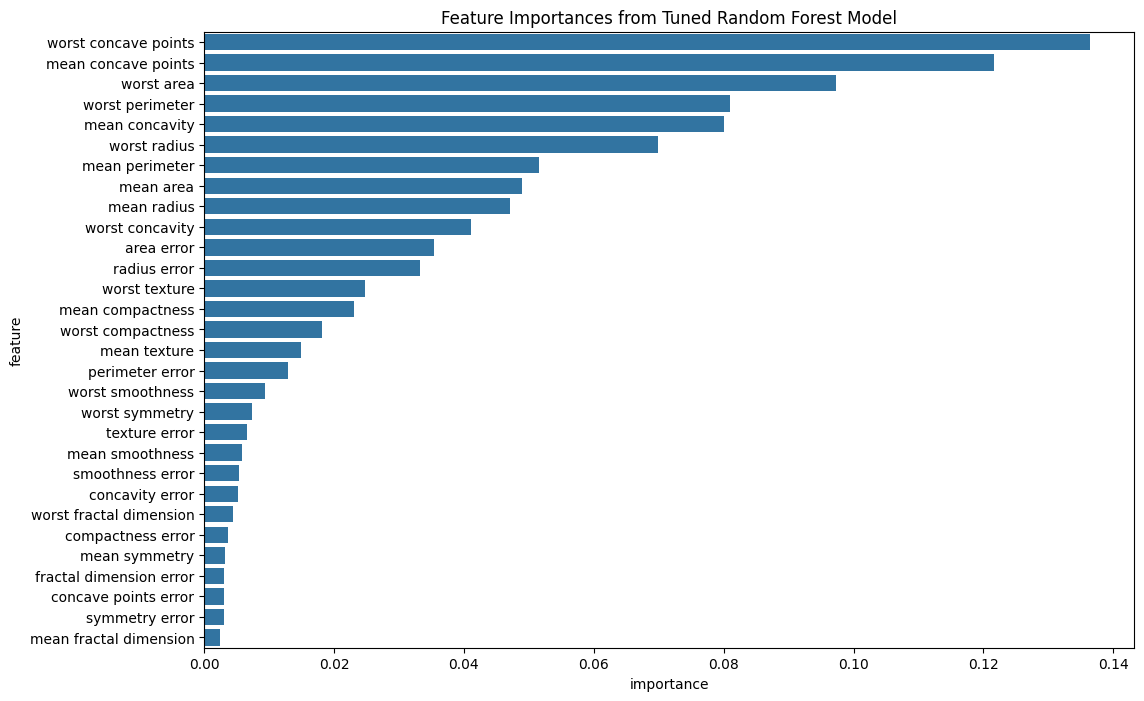

In [9]:
# Get feature importances
importances = best_rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importances from Tuned Random Forest Model')
plt.show()

## 9. Summary and Conclusion
In this notebook, we performed a detailed analysis of a Random Forest model for breast cancer classification. Here's a summary of our findings:

1.  **Baseline Model**: The baseline Random Forest model with default parameters performed very well, achieving an accuracy of approximately 0.96.
2.  **Hyperparameter Tuning**: We used `GridSearchCV` to find the optimal hyperparameters for the model. The best parameters were identified, and a new model was trained using these parameters.
3.  **Tuned Model Performance**: The tuned model achieved a slightly higher accuracy and F1-score, demonstrating the value of hyperparameter tuning, although the improvement was marginal given the strong baseline performance.
4.  **Feature Importance**: The feature importance plot revealed that features like `worst concave points`, `worst perimeter`, and `worst radius` were the most influential in the model's predictions.

**Conclusion**: The Random Forest model is a highly effective classifier for this dataset. Hyperparameter tuning provided a slight improvement in performance, and the feature importance analysis gave us insights into the key drivers of the model's predictions. This notebook demonstrates a complete workflow for building and optimizing a Random Forest model.